# Ejercicio 8. Palabras positivas, negativas y neutras

El enunciado pide determinar qué tan positivo, negativo o neutral es cada tweet, y añade una
condición que conviene tomar en serio: *«Revise para esto el preprocesamiento que le hizo a
los tweets, ¿valdrá la pena dejar los emoticones y analizarlos?»*.

Esa pregunta no es retórica. El ejercicio 3 dejó el texto en minúsculas, sin puntuación, sin
dígitos y sin palabras vacías. Cada una de esas cuatro decisiones borra una señal que un
analizador de sentimiento sí usa. Este cuaderno primero mide cuánta señal se pierde, después
decide sobre qué versión del texto se puntúa, y sólo entonces puntúa.

**Herramienta.** Se usa VADER (Hutto y Gilbert, 2014), un léxico con reglas construido y
validado sobre texto de redes sociales. A diferencia de un conteo de palabras positivas y
negativas, VADER modela la negación (`not good` no es `good`), los intensificadores
(`very bad` pesa más que `bad`), el énfasis por mayúsculas y signos de admiración, y los
emoticones. TextBlob entra como segunda opinión, para comprobar que las conclusiones no
dependen de haber elegido un léxico en particular.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, modelos, sentimiento as sen, texto as txt

warnings.filterwarnings('ignore')
config.preparar_directorios()
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 160)

crudo = pd.read_csv(config.TRAIN)
df = txt.cargar_tweets()
print(f'Tweets: {len(df):,}')
print(df['target'].value_counts().rename(config.ETIQUETAS).to_string())

Tweets: 7,613
target
No desastre    4342
Desastre       3271


## 8.1 Qué borró el preprocesamiento del ejercicio 3

Antes de decidir sobre qué texto se puntúa, hay que cuantificar lo que la limpieza agresiva
quitó. Se cuentan cuatro señales sobre el texto original: emoji Unicode, emoticones ASCII,
negaciones y el `911` que el propio enunciado pone en duda.

In [2]:
emoji = txt.contar_emoji(crudo['text'])
emoticones = txt.contar_emoticones(crudo['text'])

NEGACIONES = r"\b(no|not|never|none|nothing|cannot|can't|won't|don't|didn't|isn't|aren't|wasn't)\b"
negaciones = crudo['text'].str.lower().str.count(NEGACIONES)
exclamaciones = crudo['text'].str.count(r'!')
mayusculas = crudo['text'].str.count(r'\b[A-Z]{3,}\b')

inventario = pd.DataFrame({
    'senal': ['Emoji Unicode', 'Emoticones ASCII', 'Negaciones', 'Signos de admiración',
              'Palabras en MAYÚSCULAS'],
    'tweets_afectados': [(emoji > 0).sum(), (emoticones > 0).sum(), (negaciones > 0).sum(),
                         (exclamaciones > 0).sum(), (mayusculas > 0).sum()],
    'apariciones': [emoji.sum(), emoticones.sum(), negaciones.sum(),
                    exclamaciones.sum(), mayusculas.sum()],
})
inventario['% de tweets'] = (inventario['tweets_afectados'] / len(crudo) * 100).round(2)
print('Señales presentes en el texto ORIGINAL que la limpieza del ejercicio 3 elimina:')
print(inventario.to_string(index=False))

Señales presentes en el texto ORIGINAL que la limpieza del ejercicio 3 elimina:
                 senal  tweets_afectados  apariciones  % de tweets
         Emoji Unicode                 0            0         0.00
      Emoticones ASCII               112          117         1.47
            Negaciones               918         1028        12.06
  Signos de admiración               719         1173         9.44
Palabras en MAYÚSCULAS              1487         3741        19.53


In [3]:
# El caso del 911, que el enunciado pide valorar de forma explícita.
tiene_911 = crudo['text'].str.contains(r'\b911\b', regex=True, na=False)
tabla_911 = pd.crosstab(tiene_911, crudo['target'])
tabla_911.index = ['sin 911', 'con 911']
tabla_911.columns = [config.ETIQUETAS[c] for c in tabla_911.columns]
tabla_911['% desastre'] = (tabla_911['Desastre'] /
                           tabla_911.sum(axis=1) * 100).round(2)
print(tabla_911.to_string())

base = crudo['target'].mean() * 100
con = crudo.loc[tiene_911, 'target'].mean() * 100
print(f'\nPrevalencia de desastre en todo el conjunto : {base:.2f} %')
print(f'Prevalencia entre los tweets que dicen 911   : {con:.2f} %')
print(f'Tweets con 911: {int(tiene_911.sum())}')

         No desastre  Desastre  % desastre
sin 911         4341      3268       42.95
con 911            1         3       75.00

Prevalencia de desastre en todo el conjunto : 42.97 %
Prevalencia entre los tweets que dicen 911   : 75.00 %
Tweets con 911: 4


### Lo que dice el inventario

**No hay un solo emoji Unicode en las 7,613 filas.** La pregunta del enunciado sobre si vale
la pena conservarlos tiene, para este conjunto, una respuesta empírica y tajante: no hay nada
que conservar. Los emoticones ASCII sí aparecen, pero en 112 tweets, el 1.47 %; conservarlos
afectaría a uno de cada sesenta y ocho.

Ahora bien, sería un error concluir de ahí que la limpieza del ejercicio 3 fue inocua para el
análisis de sentimiento. Lo que esa limpieza destruye no son los emoticones sino tres señales
bastante más frecuentes:

| Señal | Tweets | % |
|---|---|---|
| Emoji Unicode | 0 | 0.00 |
| Emoticones ASCII | 112 | 1.47 |
| Signos de admiración | 719 | 9.44 |
| **Negaciones** | **918** | **12.06** |
| **Palabras en MAYÚSCULAS** | **1487** | **19.53** |

La negación es la más grave de las tres. Un analizador de polaridad que reciba `not good` sin
el `not` —y `not` es palabra vacía, así que el ejercicio 3 la elimina— leerá `good` y
puntuará el tweet como positivo, exactamente al revés. Uno de cada ocho tweets del conjunto
contiene al menos una negación.

**Sobre el 911.** El enunciado pide valorar si conviene quitarlo. La respuesta es que aquí da
lo mismo: `911` aparece en **4 tweets** de 7,613. Tres de esos cuatro son desastre real, una
proporción del 75 % contra el 42.97 % de base, pero con cuatro observaciones eso no es
evidencia de nada. La decisión del ejercicio 3 de eliminar todos los dígitos no costó ninguna
capacidad de clasificación medible.

## 8.2 Decisión sobre el texto a puntuar

Con el inventario a la vista se define una segunda limpieza, `limpieza_sentimiento`, mucho
más suave que la del ejercicio 3: sólo quita las URL, las menciones `@usuario` y la
almohadilla de los hashtag —la palabra del hashtag sí lleva contenido—, y normaliza los
espacios. Conserva mayúsculas, puntuación, negaciones y emoticones.

Las dos versiones conviven a propósito. La del ejercicio 3 sigue alimentando a los
clasificadores, porque es sobre ella que se entrenaron los modelos del ejercicio 6; la nueva
alimenta únicamente al analizador de polaridad.

In [4]:
df['texto_sentimiento'] = crudo['text'].map(txt.limpieza_sentimiento)

muestra = df.loc[[0, 12, 31], ['text', 'cleaned_text', 'texto_sentimiento']]
for i, fila in muestra.iterrows():
    print(f'--- tweet {i} ---')
    print(f"original    : {fila['text']}")
    print(f"ejercicio 3 : {fila['cleaned_text']}")
    print(f"sentimiento : {fila['texto_sentimiento']}")
    print()

--- tweet 0 ---
original    : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
ejercicio 3 : deeds reason earthquake may allah forgive us
sentimiento : Our Deeds are the Reason of this earthquake May ALLAH Forgive us all

--- tweet 12 ---
original    : #raining #flooding #Florida #TampaBay #Tampa 18 or 19 days. I've lost count 
ejercicio 3 : raining flooding florida tampabay tampa days ive lost count
sentimiento : raining flooding Florida TampaBay Tampa 18 or 19 days. I've lost count

--- tweet 31 ---
original    : @bbcmtd Wholesale Markets ablaze http://t.co/lHYXEOHY6C
ejercicio 3 : ablaze bbcmtd wholesale markets ablaze
sentimiento : Wholesale Markets ablaze



In [5]:
# Cuánto cambia la puntuación según la versión del texto que se le entregue a VADER.
compound_limpio = sen.puntuar_vader(df['cleaned_text'])['vader_compound']
compound_suave = sen.puntuar_vader(df['texto_sentimiento'])['vader_compound']

comparacion = pd.DataFrame({
    'versión del texto': ['Limpieza del ejercicio 3', 'Limpieza para sentimiento'],
    'compound medio': [compound_limpio.mean(), compound_suave.mean()],
    'neutros (%)': [(compound_limpio.abs() < sen.UMBRAL).mean() * 100,
                    (compound_suave.abs() < sen.UMBRAL).mean() * 100],
    'desv. estándar': [compound_limpio.std(), compound_suave.std()],
})
print(comparacion.round(4).to_string(index=False))

cambian = (np.sign(compound_limpio) != np.sign(compound_suave)).mean() * 100
print(f'\nTweets que cambian de signo entre una y otra versión: {cambian:.2f} %')
print(f'Correlación de Pearson entre las dos puntuaciones: {compound_limpio.corr(compound_suave):.4f}')

        versión del texto  compound medio  neutros (%)  desv. estándar
 Limpieza del ejercicio 3         -0.2080      24.7471          0.4831
Limpieza para sentimiento         -0.1441      24.9704          0.4648

Tweets que cambian de signo entre una y otra versión: 7.46 %
Correlación de Pearson entre las dos puntuaciones: 0.8958


### Cuál de las dos versiones puntuar

Las dos puntuaciones correlacionan a 0.8958, pero **el 7.46 % de los tweets cambia de signo**
según cuál de los dos textos reciba VADER. Ese 7.46 % son 568 tweets a los que se les asignaría
el tono contrario.

El sesgo tiene además una dirección clara: sobre el texto del ejercicio 3 la media de
`compound` es **-0.2080**, contra **-0.1441** sobre el texto con limpieza suave. La limpieza
agresiva hace que el corpus entero parezca más negativo de lo que es, y el mecanismo es el que
se anticipaba en el inventario: al borrar las negaciones desaparece el `not` que le daría
vuelta a la valencia de la palabra siguiente, de modo que `not bad` se contabiliza como `bad`.

Se puntúa entonces sobre `texto_sentimiento`. La limpieza del ejercicio 3 se conserva intacta
para los clasificadores, que es para lo que fue diseñada.

## 8.3 Puntuación y clasificación en positivo, negativo y neutro

Se puntúa sobre el texto con la limpieza suave. La regla de corte es la estándar de VADER:
`compound >= 0.05` es positivo, `compound <= -0.05` es negativo y el resto es neutro.

In [6]:
df = sen.puntuar(df, 'texto_sentimiento')

reparto = df['polaridad'].value_counts().reindex(sen.CLASES)
reparto_pct = (reparto / len(df) * 100).round(2)
print('Reparto de polaridad en todo el conjunto:')
print(pd.DataFrame({'tweets': reparto, '%': reparto_pct}).to_string())

print('\nReparto por categoría (% dentro de cada categoría):')
cruce = pd.crosstab(df['target'], df['polaridad'], normalize='index').reindex(columns=sen.CLASES)
cruce.index = [config.ETIQUETAS[i] for i in cruce.index]
print((cruce * 100).round(2).to_string())

Reparto de polaridad en todo el conjunto:
           tweets      %
polaridad               
negativo     3747  49.22
neutro       1901  24.97
positivo     1965  25.81

Reparto por categoría (% dentro de cada categoría):
polaridad    negativo  neutro  positivo
No desastre     42.81   24.34     32.84
Desastre        57.72   25.80     16.48


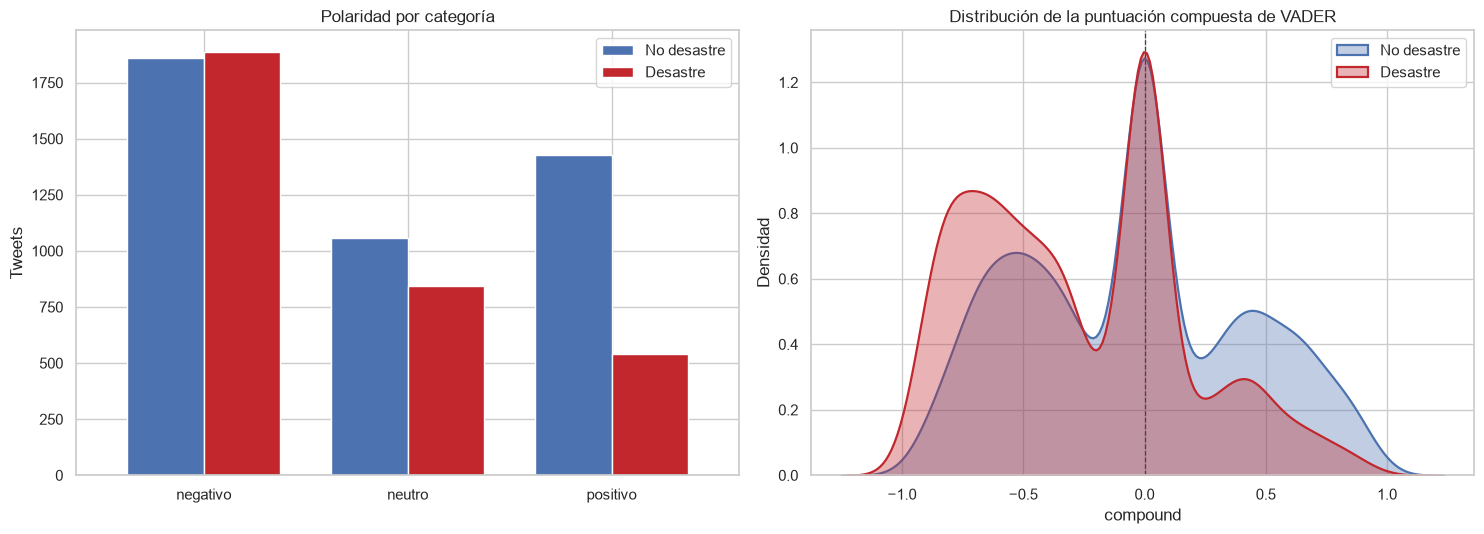

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

conteos = pd.crosstab(df['polaridad'], df['target']).reindex(sen.CLASES)
conteos.columns = [config.ETIQUETAS[c] for c in conteos.columns]
conteos.plot(kind='bar', ax=axes[0], color=['#4c72b0', '#c1272d'], rot=0, width=0.75)
axes[0].set_title('Polaridad por categoría')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tweets')
axes[0].legend(title='')

for objetivo, color, etiqueta in [(0, '#4c72b0', 'No desastre'), (1, '#c1272d', 'Desastre')]:
    sns.kdeplot(df.loc[df['target'] == objetivo, 'vader_compound'], ax=axes[1],
                fill=True, alpha=0.35, color=color, label=etiqueta, linewidth=1.6)
axes[1].axvline(0, color='#444444', linewidth=0.9, linestyle='--')
axes[1].set_title('Distribución de la puntuación compuesta de VADER')
axes[1].set_xlabel('compound')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.savefig(config.FIGURAS / 'polaridad.png', dpi=150, bbox_inches='tight')
plt.show()

### Lectura del reparto

Casi la mitad del conjunto es negativo (49.22 %) y las dos categorías se separan con claridad:

| Categoría | Negativo | Neutro | Positivo |
|---|---|---|---|
| No desastre | 42.81 % | 24.34 % | 32.84 % |
| Desastre | 57.72 % | 25.80 % | 16.48 % |

Conviene fijarse en dónde está realmente la diferencia. En el extremo negativo la brecha es de
15 puntos, un factor de 1.35. En el extremo positivo es de 16 puntos, pero sobre una base mucho
menor: un factor de **2.0**. Lo que distingue a un tweet de desastre no es tanto que sea más
negativo como que **casi nunca es positivo**. La proporción de neutros, en cambio, es
prácticamente la misma en ambas categorías (25.80 % contra 24.34 %), lo que indica que la
polaridad no separa por el volumen de tweets sin carga sino por el reparto entre los extremos.

## 8.4 Las palabras que aportan la polaridad

VADER puntúa un tweet sumando la valencia de las palabras de su léxico que aparecen en él.
Conviene ver cuáles son esas palabras en este conjunto, porque son las que después explican
el resultado del ejercicio 9.

In [8]:
from collections import Counter

lexico = sen._ANALIZADOR.lexicon
positivas, negativas = Counter(), Counter()
for texto_tweet in df['texto_sentimiento']:
    for palabra in str(texto_tweet).lower().split():
        limpia = palabra.strip('.,!?;:"()[]')
        valor = lexico.get(limpia)
        if valor is None:
            continue
        (positivas if valor > 0 else negativas)[limpia] += 1

top_pos = pd.DataFrame(positivas.most_common(15), columns=['palabra', 'frecuencia'])
top_pos['valencia'] = top_pos['palabra'].map(lexico)
top_neg = pd.DataFrame(negativas.most_common(15), columns=['palabra', 'frecuencia'])
top_neg['valencia'] = top_neg['palabra'].map(lexico)

print(f'Palabras del léxico de VADER presentes: {len(positivas)} positivas, {len(negativas)} negativas')
print('\n--- 15 palabras POSITIVAS más frecuentes ---')
print(top_pos.to_string(index=False))
print('\n--- 15 palabras NEGATIVAS más frecuentes ---')
print(top_neg.to_string(index=False))

Palabras del léxico de VADER presentes: 632 positivas, 802 negativas

--- 15 palabras POSITIVAS más frecuentes ---
palabra  frecuencia  valencia
   like         345       1.5
   love         100       3.2
   good          87       1.9
   want          79       0.3
   best          73       3.2
   help          70       1.7
 please          68       1.3
    lol          68       1.8
  great          60       3.1
    god          55       1.1
    top          54       0.8
   hope          52       1.9
   well          45       1.1
natural          45       1.5
  liked          44       1.8

--- 15 palabras NEGATIVAS más frecuentes ---
  palabra  frecuencia  valencia
       no         252      -1.2
     fire         240      -1.4
emergency         154      -1.6
 disaster         148      -3.1
    crash         116      -1.7
  suicide         109      -3.5
     bomb         102      -2.2
   killed          96      -3.5
     dead          94      -3.3
   attack          94      -2.1
      w

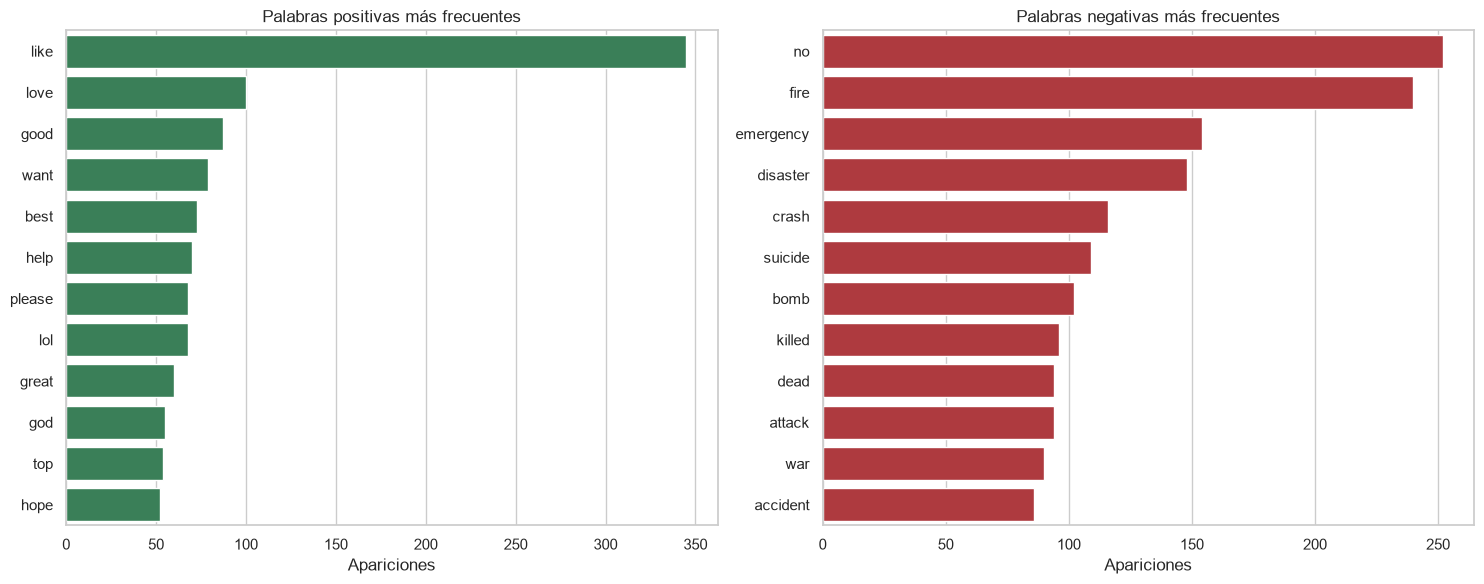

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=top_pos.head(12), y='palabra', x='frecuencia', ax=axes[0], color='#2e8b57')
axes[0].set_title('Palabras positivas más frecuentes')
axes[0].set_xlabel('Apariciones')
axes[0].set_ylabel('')
sns.barplot(data=top_neg.head(12), y='palabra', x='frecuencia', ax=axes[1], color='#c1272d')
axes[1].set_title('Palabras negativas más frecuentes')
axes[1].set_xlabel('Apariciones')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig(config.FIGURAS / 'palabras_polaridad.png', dpi=150, bbox_inches='tight')
plt.show()

### Una advertencia sobre qué es esta variable

La lista de palabras negativas es reveladora, y conviene detenerse en ella porque condiciona
el ejercicio 10. Las quince negativas más frecuentes son `no`, `fire`, `emergency`,
`disaster`, `crash`, `suicide`, `bomb`, `killed`, `dead`, `attack`, `war`, `accident`,
`collapse`, `death`, `fatal`. Salvo la primera, **son el vocabulario de desastre**.

Las positivas, en cambio, son conversacionales y genéricas: `like`, `love`, `good`, `want`,
`best`, `help`, `please`, `lol`, `great`.

Esto significa que la negatividad que se está midiendo no es una dimensión independiente del
texto: es un promedio ponderado de la presencia de un puñado de palabras que el clasificador
TF-IDF del ejercicio 6 ya está usando como predictoras, cada una por separado y con su propio
peso aprendido. Es la razón por la que hay que ser prudente al anticipar el resultado del
ejercicio 10, y se retomará allí.

## 8.5 Contraste con un segundo léxico

Una conclusión que sólo se sostiene con VADER es frágil. Se repite la clasificación con
TextBlob y se mide en qué proporción de tweets coinciden ambos.

In [10]:
pol_textblob = sen.clasificar_polaridad(df['tb_polaridad'], umbral=0.05)
acuerdo = (df['polaridad'] == pol_textblob).mean() * 100
print(f'Acuerdo entre VADER y TextBlob: {acuerdo:.2f} % de los tweets')
print(f'Correlación de Spearman entre ambas puntuaciones: '
      f"{df['vader_compound'].corr(df['tb_polaridad'], method='spearman'):.4f}")

matriz = pd.crosstab(df['polaridad'], pol_textblob).reindex(index=sen.CLASES, columns=sen.CLASES)
matriz.index.name, matriz.columns.name = 'VADER', 'TextBlob'
print('\nCoincidencias y desacuerdos:')
print(matriz.fillna(0).astype(int).to_string())

Acuerdo entre VADER y TextBlob: 46.81 % de los tweets
Correlación de Spearman entre ambas puntuaciones: 0.3937

Coincidencias y desacuerdos:
TextBlob  negativo  neutro  positivo
VADER                               
negativo      1127    1821       799
neutro         149    1327       425
positivo       193     662      1110


### Contraste con TextBlob

El acuerdo entre los dos léxicos es de **46.81 %** y la correlación de Spearman de **0.3937**.
Es un acuerdo bajo, y hay que decirlo antes de apoyarse en ninguno de los dos.

La tabla de desacuerdos muestra de dónde viene: la celda más poblada fuera de la diagonal son
los **1,821 tweets que VADER llama negativos y TextBlob llama neutros**. La causa es el tamaño
y la composición de los léxicos. El analizador por omisión de TextBlob se apoya en un
diccionario de adjetivos; `killed`, `bomb`, `crash` o `collapse` son sustantivos y verbos que
no están en él, y por eso los puntúa en cero. VADER sí los cubre, y cubre además la negación y
el énfasis.

Para un corpus de tweets sobre desastres, donde la carga negativa la llevan sustantivos y no
adjetivos, VADER es el instrumento adecuado y es el que se usa para decidir. TextBlob se
conserva en el conjunto guardado y se vuelve a usar en el ejercicio 9, no para clasificar sino
para comprobar que la **dirección** del hallazgo principal no depende del léxico elegido.

In [11]:
# El resultado se guarda para los cuadernos 09 y 10.
columnas = ['id', 'keyword', 'location', 'text', 'target', 'cleaned_text',
            'texto_sentimiento', 'word_count', 'vader_neg', 'vader_neu', 'vader_pos',
            'vader_compound', 'tb_polaridad', 'tb_subjetividad', 'polaridad', 'negatividad']
df[columnas].to_csv(config.PROCESADO / 'train_sentimiento.csv', index=False)
print(f"Guardado: {config.PROCESADO / 'train_sentimiento.csv'} con {len(df):,} filas")

Guardado: /Users/fabianprado/Documents/projects/2026 - 2 /data-science/lab/Lab5/processed/train_sentimiento.csv con 7,613 filas
